# PEEC Integration Public Demo

Public, result-saved front door for PEEC integration. It deliberately separates maintained public demos from validation, source-API, and cleanup-review scripts in the 130-file examples catalog.

In [1]:
from pathlib import Path
import json
from IPython.display import Markdown, Image, display
CWD = Path.cwd()
if (CWD / 'public_demo_results.json').exists():
    NOTEBOOK_DIR = CWD
    REPO = NOTEBOOK_DIR.parents[1]
else:
    REPO = CWD
    NOTEBOOK_DIR = REPO / 'docs' / 'peec_integration'
demo = json.loads((NOTEBOOK_DIR / 'public_demo_results.json').read_text(encoding='utf-8'))
catalog = json.loads((NOTEBOOK_DIR / 'examples_catalog_results.json').read_text(encoding='utf-8'))
print(json.dumps(demo['summary'], indent=2, ensure_ascii=False))

{
  "selected_demo_count": 10,
  "selected_figure_count": 5,
  "catalog_script_count": 130,
  "catalog_artifact_count": 58,
  "protected_script_count": 130,
  "cleanup_review_count": 63,
  "public_demo_candidate_count": 49,
  "validation_candidate_count": 42,
  "src_api_review_count": 19
}


In [2]:
display(Markdown('## Public route\n\nPEEC has three layers here: [public_demo.ipynb](public_demo.ipynb) is the human front door, [peec_showcase.ipynb](peec_showcase.ipynb) carries the verified numerical figures, and [examples_catalog.ipynb](examples_catalog.ipynb) is the full source/hash catalog. The archive intentionally includes cleanup-review scripts; they are not all public demos.'))

## Public route

PEEC has three layers here: [public_demo.ipynb](public_demo.ipynb) is the human front door, [peec_showcase.ipynb](peec_showcase.ipynb) carries the verified numerical figures, and [examples_catalog.ipynb](examples_catalog.ipynb) is the full source/hash catalog. The archive intentionally includes cleanup-review scripts; they are not all public demos.

In [3]:
rows = sorted(catalog['summary']['lane_counts'].items())
md = '## 130 scripts are not 130 public demos\n\n' + '\n'.join(['| lane | count |', '| --- | ---: |'] + [f'| {k} | {v} |' for k, v in rows])
md += f"\n\nCleanup-review count: **{catalog['summary'].get('cleanup_review_count', 0)}**. These need validation/src/memory cleanup before any examples rerouting."
display(Markdown(md))

## 130 scripts are not 130 public demos

| lane | count |
| --- | ---: |
| docs_analysis_helper_or_retired_review | 6 |
| docs_application_demo | 9 |
| docs_basic_peec_demo | 8 |
| docs_cad_filament_demo | 21 |
| docs_mesh_pipeline_demo | 8 |
| docs_mor_spice_demo | 7 |
| docs_showcase_candidate | 10 |
| src_api_plus_validation_review | 19 |
| validation_benchmark_candidate | 3 |
| validation_test_candidate | 39 |

Cleanup-review count: **63**. These need validation/src/memory cleanup before any examples rerouting.

In [4]:
if demo['cleanup_review_sample']:
    rows = [[x['path'], x['lane'], x['reason']] for x in demo['cleanup_review_sample'][:25]]
    md = '## Cleanup-review sample\n\n' + '\n'.join(['| path | lane | reason |', '| --- | --- | --- |'] + [f'| `{a}` | {b} | {c} |' for a,b,c in rows])
    display(Markdown(md))

## Cleanup-review sample

| path | lane | reason |
| --- | --- | --- |
| `examples/peec_integration/analysis/analyze_dowell_prima.py` | docs_mor_spice_demo | analysis scratch/helper; docs-coupled helper or cleanup candidate |
| `examples/peec_integration/analysis/analyze_tet_ordering.py` | docs_analysis_helper_or_retired_review | analysis scratch/helper; docs-coupled helper or cleanup candidate |
| `examples/peec_integration/analysis/compare_symmetrized_solve.py` | docs_analysis_helper_or_retired_review | comparison helper; validation or cleanup candidate |
| `examples/peec_integration/analysis/demo_analysis_framework.py` | docs_analysis_helper_or_retired_review | analysis/helper lane; not a front-page public demo unless tied to a result notebook |
| `examples/peec_integration/analysis/evaluate_peec_formula_accuracy.py` | docs_analysis_helper_or_retired_review | analysis/helper lane; not a front-page public demo unless tied to a result notebook |
| `examples/peec_integration/analysis/generate_paper_figures.py` | docs_analysis_helper_or_retired_review | analysis/helper lane; not a front-page public demo unless tied to a result notebook |
| `examples/peec_integration/analysis/measure_msc_asymmetry.py` | docs_analysis_helper_or_retired_review | measurement helper; docs-coupled helper or cleanup candidate |
| `examples/peec_integration/benchmarks/benchmark_panel_vs_ngbem.py` | validation_benchmark_candidate | verification/benchmark lane; not a public demo until promoted to validation_test with durable JSON |
| `examples/peec_integration/benchmarks/vf_benchmark_same_data.py` | validation_benchmark_candidate | verification/benchmark lane; not a public demo until promoted to validation_test with durable JSON |
| `examples/peec_integration/coupled/test_delta_L_robustness.py` | src_api_plus_validation_review | test-like script under examples; should move to validation_test/tests |
| `examples/peec_integration/coupled/validate_fem_back_reaction.py` | validation_test_candidate | verification/benchmark lane; not a public demo until promoted to validation_test with durable JSON |
| `examples/peec_integration/coupled/verify_multielement_msc.py` | validation_test_candidate | verification/benchmark lane; not a public demo until promoted to validation_test with durable JSON |
| `examples/peec_integration/filament_coil/cad_sweep_smoke.py` | docs_cad_filament_demo | smoke script; should become a small test or be deleted after coverage |
| `examples/peec_integration/filament_coil/circle_and_crosstype_smoke.py` | docs_cad_filament_demo | smoke script; should become a small test or be deleted after coverage |
| `examples/peec_integration/filament_coil/compare_filament_vs_centerline.py` | docs_cad_filament_demo | comparison helper; validation or cleanup candidate |
| `examples/peec_integration/filament_coil/compare_ihbem_peec_vs_tiera.py` | docs_cad_filament_demo | comparison helper; validation or cleanup candidate |
| `examples/peec_integration/filament_coil/compare_peec_vs_tier_a.py` | docs_cad_filament_demo | comparison helper; validation or cleanup candidate |
| `examples/peec_integration/filament_coil/compare_tier_a_vs_ngbem.py` | docs_cad_filament_demo | comparison helper; validation or cleanup candidate |
| `examples/peec_integration/filament_coil/from_step_smoke.py` | docs_cad_filament_demo | smoke script; should become a small test or be deleted after coverage |
| `examples/peec_integration/filament_coil/loft_taper_smoke.py` | docs_cad_filament_demo | smoke script; should become a small test or be deleted after coverage |
| `examples/peec_integration/filament_coil/optimize_round_torus_claude.py` | docs_cad_filament_demo | agent-named optimization scratch; keep out of public demo and review for distill/delete |
| `examples/peec_integration/filament_coil/optimize_round_torus_random.py` | docs_cad_filament_demo | optimization exploration; public only after distilled result notebook |
| `examples/peec_integration/filament_coil/polygon_and_b123d_smoke.py` | docs_cad_filament_demo | smoke script; should become a small test or be deleted after coverage |
| `examples/peec_integration/filament_coil/smoke_racetrack_tier_a.py` | docs_cad_filament_demo | smoke script; should become a small test or be deleted after coverage |
| `examples/peec_integration/ngsbem_peec_demo/benchmark_4case.py` | validation_benchmark_candidate | verification/benchmark lane; not a public demo until promoted to validation_test with durable JSON |

In [5]:
commands = {
    'examples/peec_integration/basic_peec/demo_peec_simple_loop.py': 'python examples/peec_integration/basic_peec/demo_peec_simple_loop.py',
    'examples/peec_integration/basic_peec/demo_frequency_response.py': 'python examples/peec_integration/basic_peec/demo_frequency_response.py',
    'examples/peec_integration/gmsh_models/demo_gmsh_ports_peec.py': 'python examples/peec_integration/gmsh_models/demo_gmsh_ports_peec.py',
    'examples/peec_integration/spice/demo_peec_prima_reduction.py': 'python examples/peec_integration/spice/demo_peec_prima_reduction.py',
}
rows=[]
for r in demo['selected_records']:
    arts = ', '.join(f'[{Path(a["path"]).name}](../../{a["path"]})' for a in r.get('sibling_artifacts', [])[:3]) or '-'
    rows.append([f'[`{r["path"]}`](../../{r["path"]})', r['lane'], f'`{commands.get(r["path"], "python " + r["path"])}`', arts, r['source']['summary']])
md = '## Representative runnable companions\n\n' + '\n'.join(['| script | lane | command | artifacts | summary |', '| --- | --- | --- | --- | --- |'] + [f'| {a} | {b} | {c} | {d} | {e} |' for a,b,c,d,e in rows])
display(Markdown(md))

## Representative runnable companions

| script | lane | command | artifacts | summary |
| --- | --- | --- | --- | --- |
| [`examples/peec_integration/basic_peec/demo_peec_simple_loop.py`](../../examples/peec_integration/basic_peec/demo_peec_simple_loop.py) | docs_basic_peec_demo | `python examples/peec_integration/basic_peec/demo_peec_simple_loop.py` | - | Simple PEEC Analysis for Circular Coil Uses Radia's verified PEEC solver with analytical loop geometry. Compares with GMSH mesh for validation. This is the CORRECT approach - use t |
| [`examples/peec_integration/basic_peec/demo_frequency_response.py`](../../examples/peec_integration/basic_peec/demo_frequency_response.py) | docs_basic_peec_demo | `python examples/peec_integration/basic_peec/demo_frequency_response.py` | - | Demonstration of Frequency Response Analysis This script demonstrates frequency response analysis for both: 1. PEEC conductors (impedance Z(f) with skin effect) 2. MMM magnetic mat |
| [`examples/peec_integration/gmsh_models/demo_gmsh_ports_peec.py`](../../examples/peec_integration/gmsh_models/demo_gmsh_ports_peec.py) | docs_mesh_pipeline_demo | `python examples/peec_integration/gmsh_models/demo_gmsh_ports_peec.py` | - | PEEC Analysis with Port-Defined GMSH Mesh Workflow: 1. Load GMSH mesh with port definitions (circular_coil_with_ports.msh) 2. Extract port regions (port_positive, port_negative) 3. |
| [`examples/peec_integration/spice/demo_peec_prima_reduction.py`](../../examples/peec_integration/spice/demo_peec_prima_reduction.py) | docs_mor_spice_demo | `python examples/peec_integration/spice/demo_peec_prima_reduction.py` | - | DC PEEC Model Reduction using Lanczos-based PRIMA Transform This example demonstrates model order reduction (MOR) for PEEC systems using the Lanczos algorithm to reduce PRIMA I for |
| [`examples/peec_integration/applications/demo_induction_heating.py`](../../examples/peec_integration/applications/demo_induction_heating.py) | docs_application_demo | `python examples/peec_integration/applications/demo_induction_heating.py` | [demo_induction_heating.png](../../examples/peec_integration/applications/demo_induction_heating.png) | Induction Heating Analysis with PEEC and Surface Impedance This demo shows induction heating coil analysis: 1. Coil-workpiece electromagnetic coupling 2. Surface impedance with ski |
| [`examples/peec_integration/wpt/demo_wpt.py`](../../examples/peec_integration/wpt/demo_wpt.py) | docs_application_demo | `python examples/peec_integration/wpt/demo_wpt.py` | [demo_wpt_basic.png](../../examples/peec_integration/wpt/demo_wpt_basic.png), [demo_wpt_multi_turn.png](../../examples/peec_integration/wpt/demo_wpt_multi_turn.png), [demo_wpt_s_params.png](../../examples/peec_integration/wpt/demo_wpt_s_params.png) | Demonstration of Multi-Port WPT (Wireless Power Transfer) Analysis This script demonstrates: 1. Two-coil WPT system with mutual inductance 2. Coupling coefficient k vs frequency 3. |
| [`examples/peec_integration/ngsbem_peec_demo/verify_peec_vs_ngsbem.py`](../../examples/peec_integration/ngsbem_peec_demo/verify_peec_vs_ngsbem.py) | validation_test_candidate | `python examples/peec_integration/ngsbem_peec_demo/verify_peec_vs_ngsbem.py` | - | verify_peec_vs_ngsbem.py Cross-verification of inductance computation: 1. PEEC (geometric Neumann formula via peec_matrices) 2. NGSBEM (Laplace SL BEM via bem_inductance) 3. Radia  |
| [`examples/peec_integration/coupled/demo_coupled_frequency_sweep.py`](../../examples/peec_integration/coupled/demo_coupled_frequency_sweep.py) | src_api_plus_validation_review | `python examples/peec_integration/coupled/demo_coupled_frequency_sweep.py` | - | demo_coupled_frequency_sweep.py Frequency-domain coupled PEEC + MMM analysis with: - Surface impedance (Dowell SIBC) for skin effect - Magnetic coupling (Delta_L) from ferrite core |
| [`examples/peec_integration/filament_coil/ih_cad_first_demo.py`](../../examples/peec_integration/filament_coil/ih_cad_first_demo.py) | docs_cad_filament_demo | `python examples/peec_integration/filament_coil/ih_cad_first_demo.py` | - | ih_cad_first_demo.py End-to-end CAD-first IH (induction heating) demo. Demonstrates the full workflow: (1) Design the coil in build123d / CoilBuilder (CAD-first) (2) PEEC filament  |
| [`examples/peec_integration/benchmarks/benchmark_panel_vs_ngbem.py`](../../examples/peec_integration/benchmarks/benchmark_panel_vs_ngbem.py) | validation_benchmark_candidate | `python examples/peec_integration/benchmarks/benchmark_panel_vs_ngbem.py` | - | benchmark_panel_vs_ngbem.py Benchmark comparison: Radia C++ panels (FastImp-style) vs ngbem (NGSolve BEM) Compares: 1. P matrix (potential coefficients) - Wilton collocation vs Gal |

## Saved figures from the verified PEEC showcase

### `docs/peec_integration/derive_dowell_cf_algorithm.png`  
sha256 `3f132a27c4f39846`

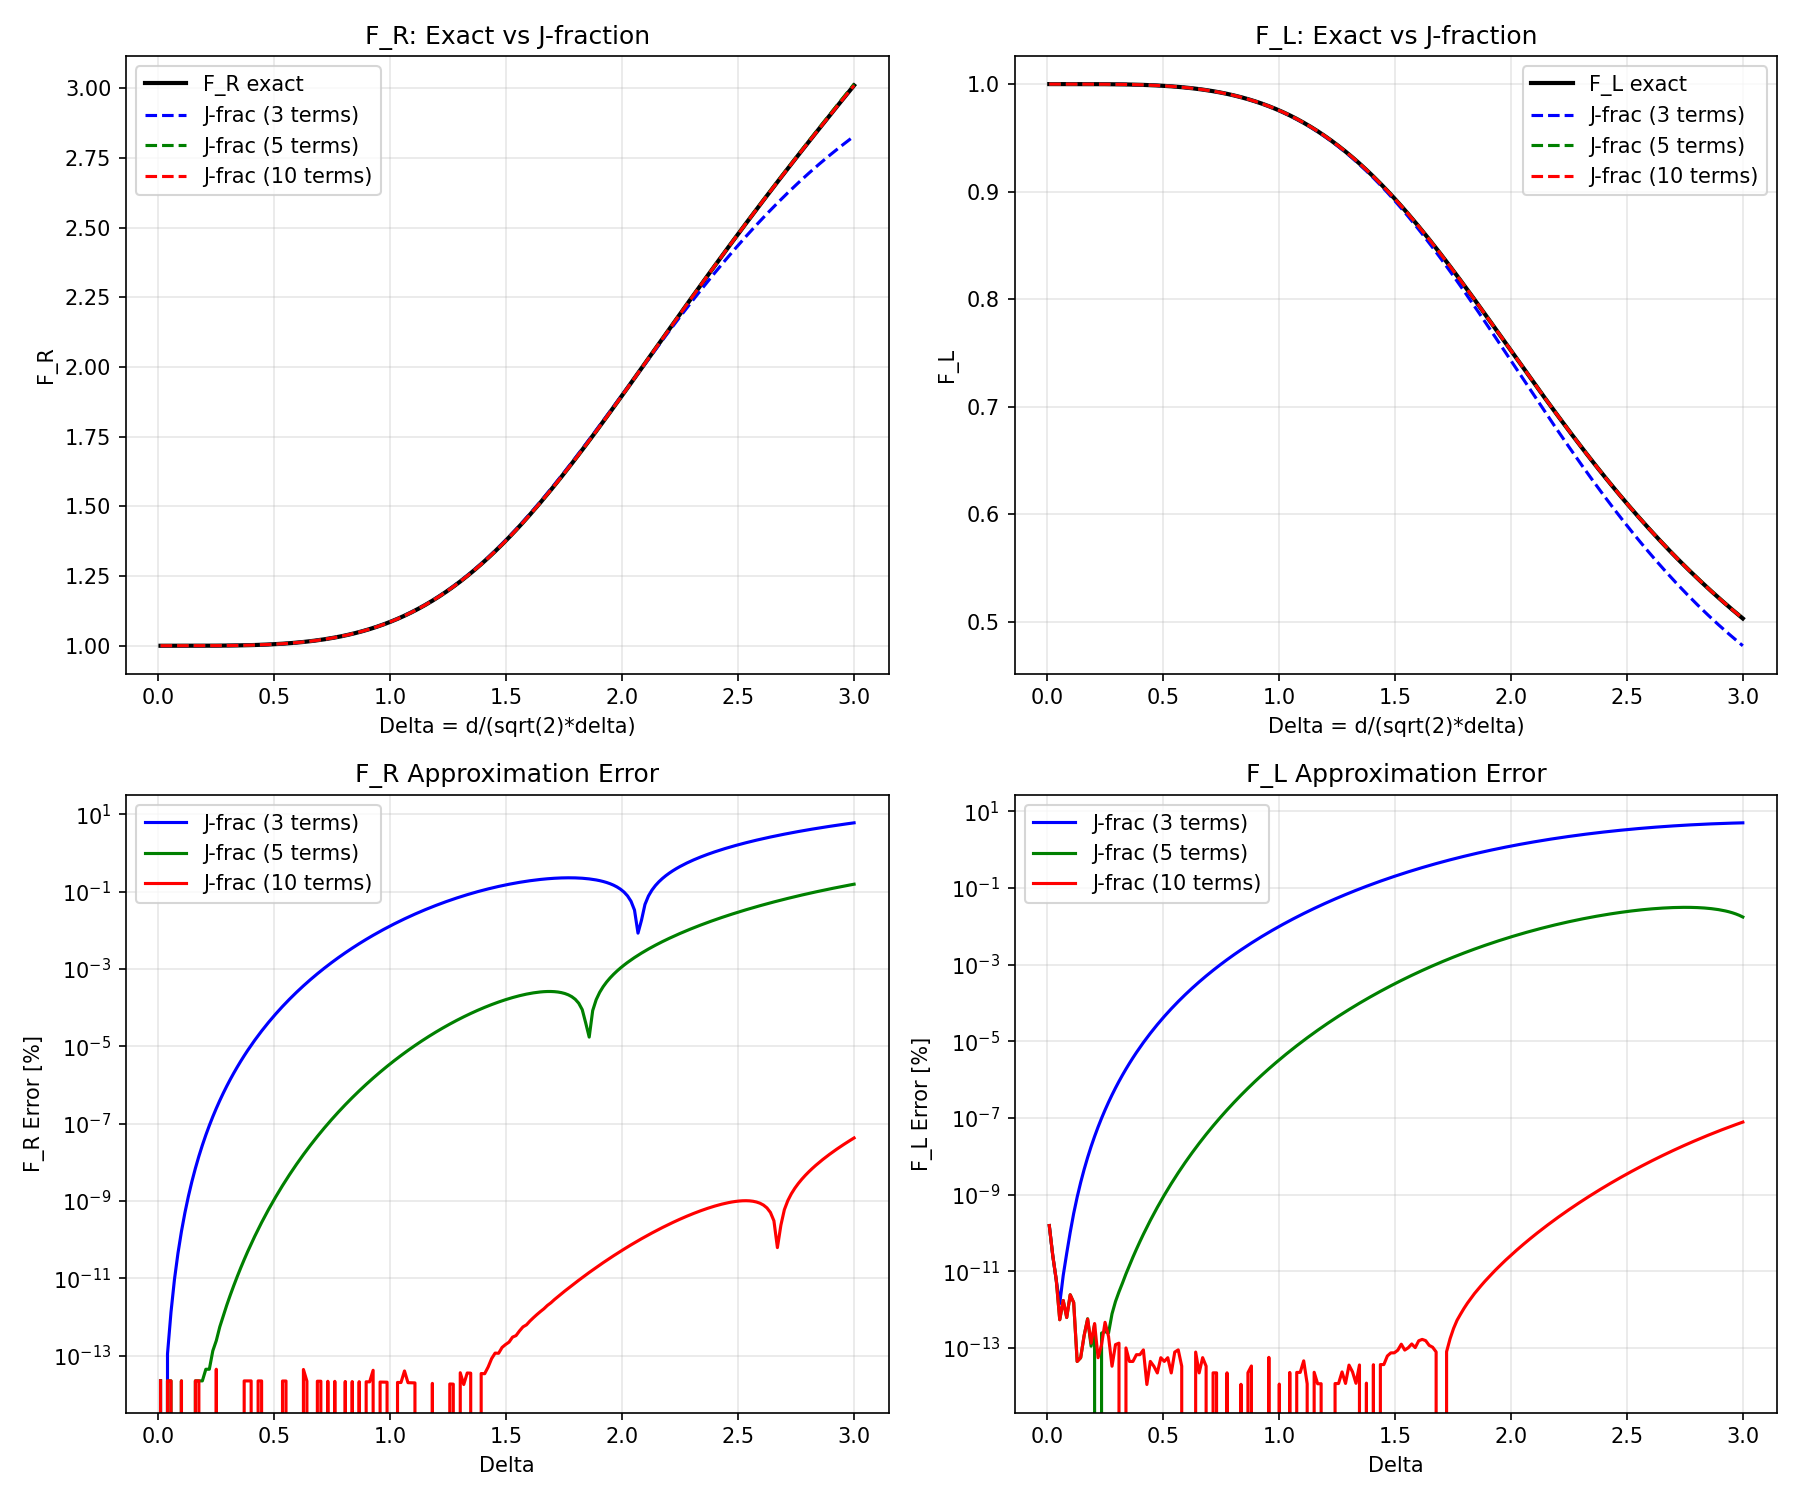

### `docs/peec_integration/figures/fig1_peec_matrix_verification.png`  
sha256 `439e099fbd884785`

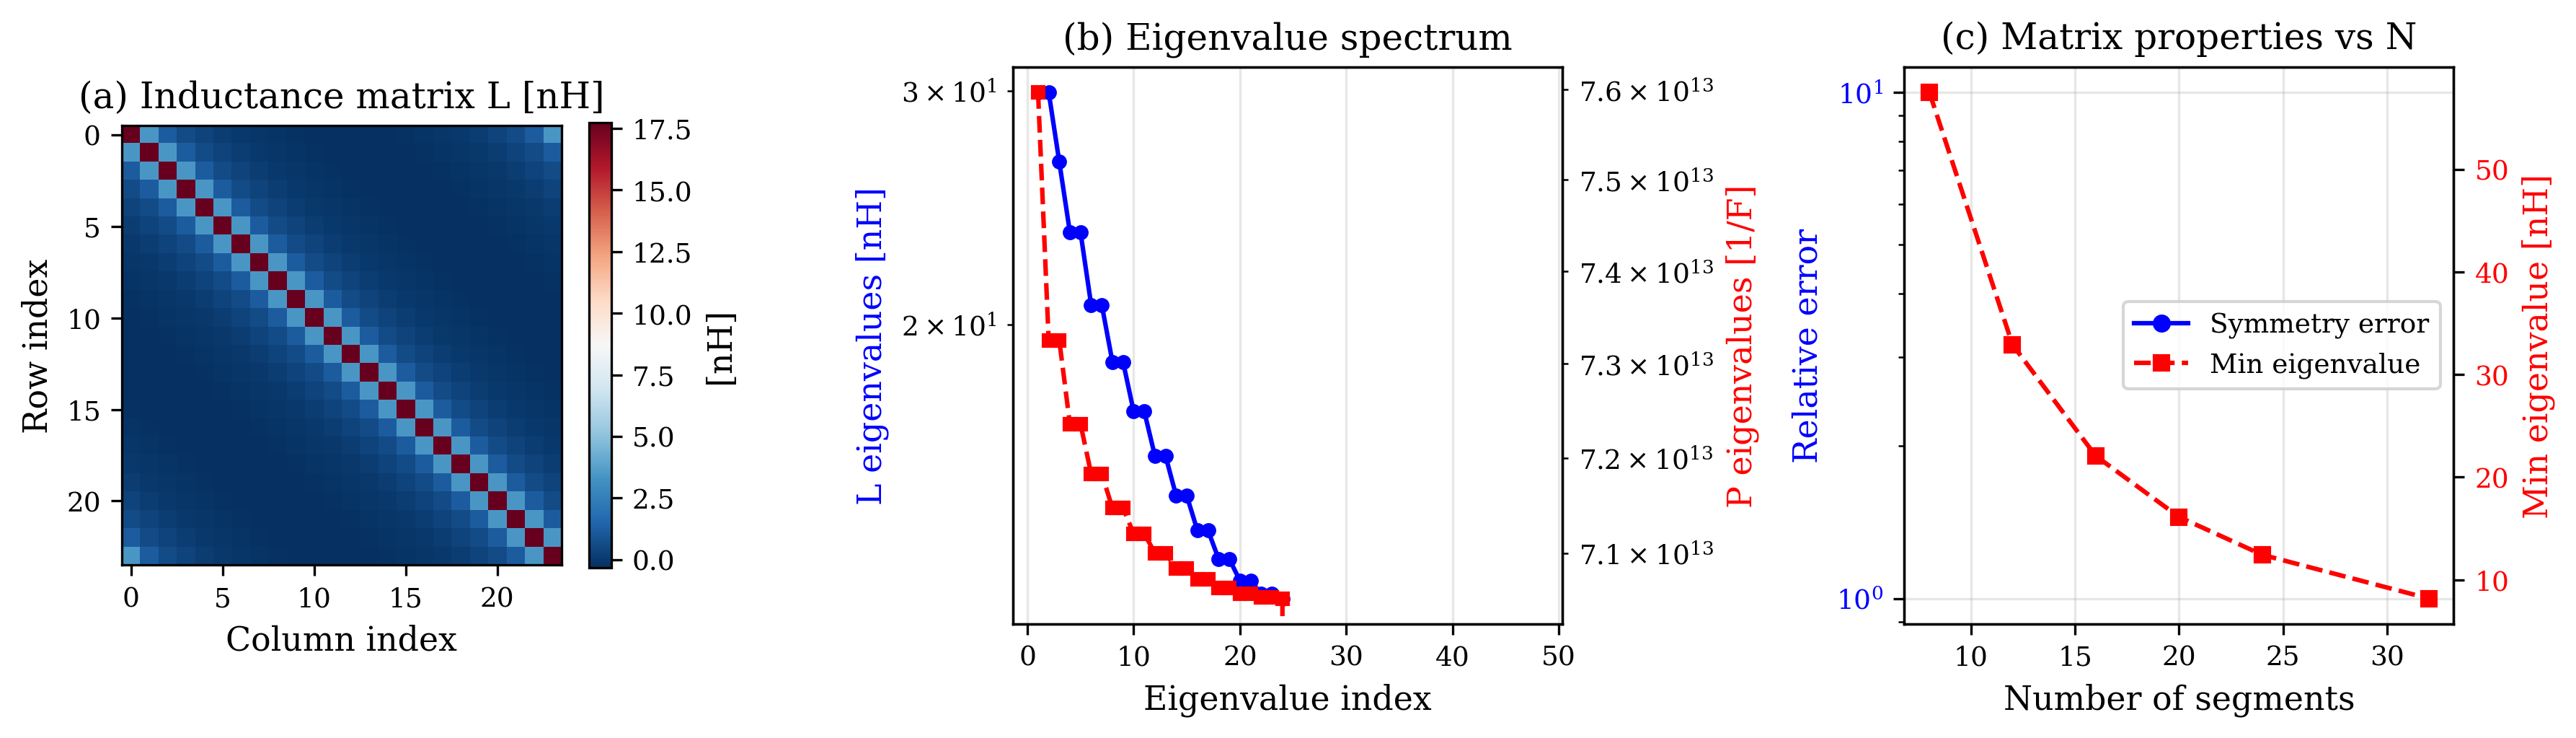

### `docs/peec_integration/figures/fig2_prima_accuracy.png`  
sha256 `017bc1ef6773b550`

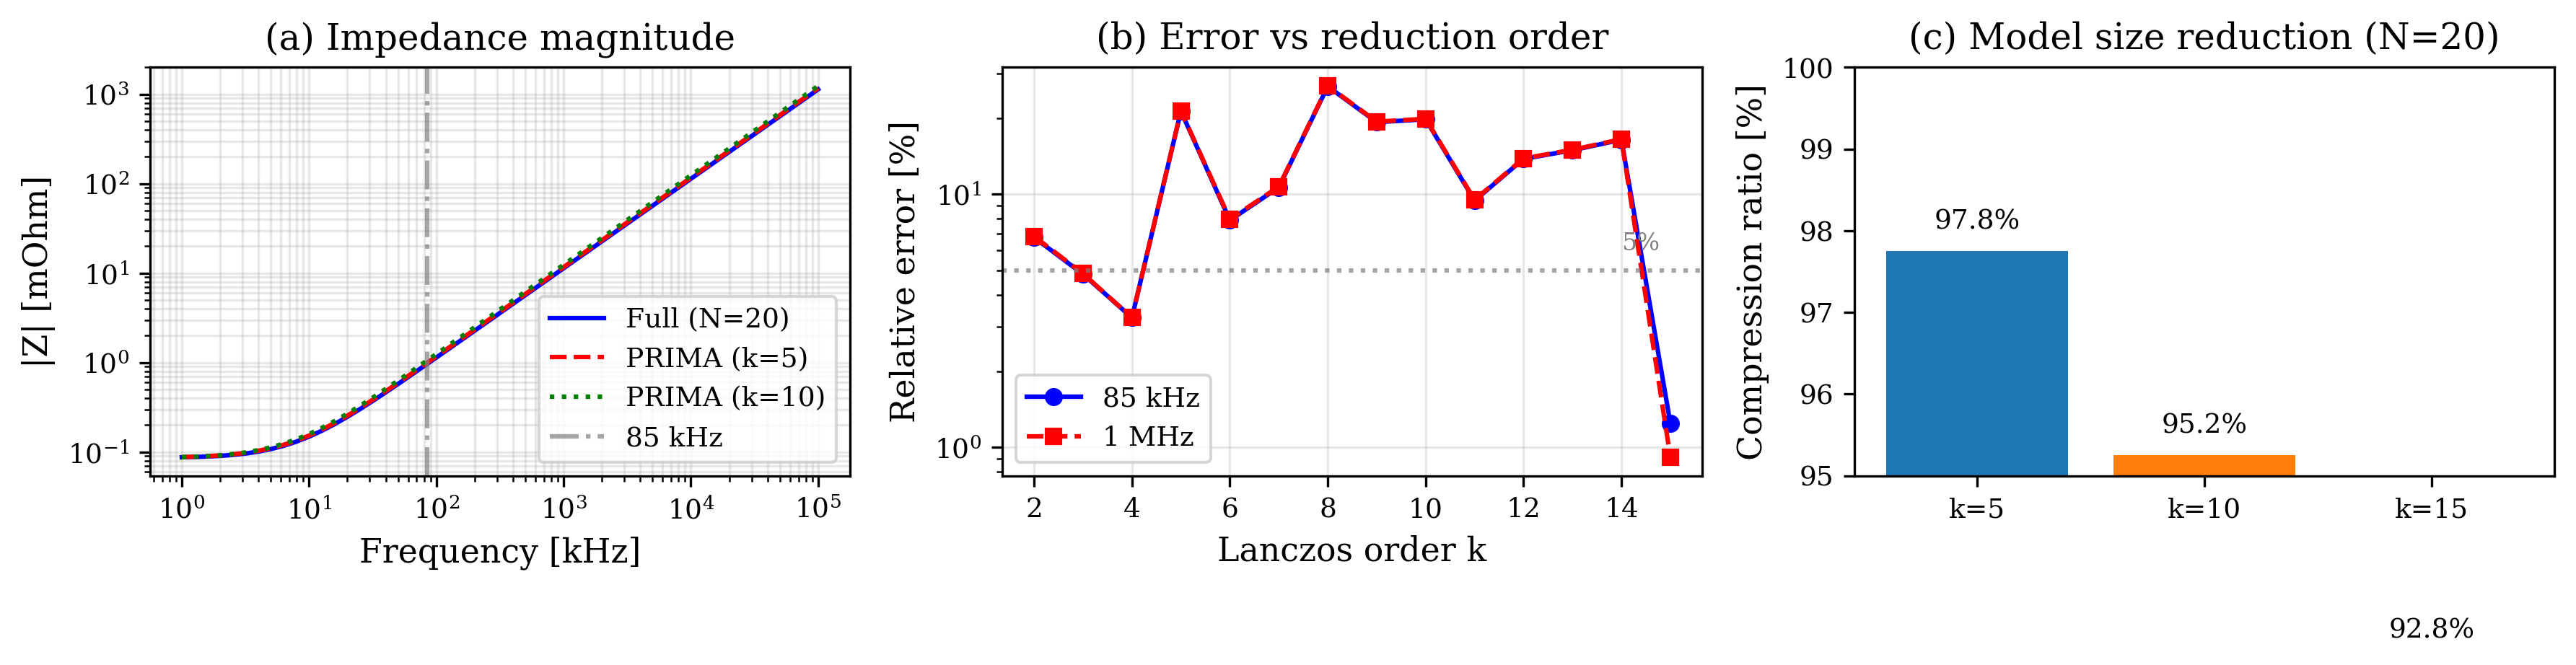

### `docs/peec_integration/figures/fig3_adaptive_msc_error.png`  
sha256 `ca1f736887ea09cc`

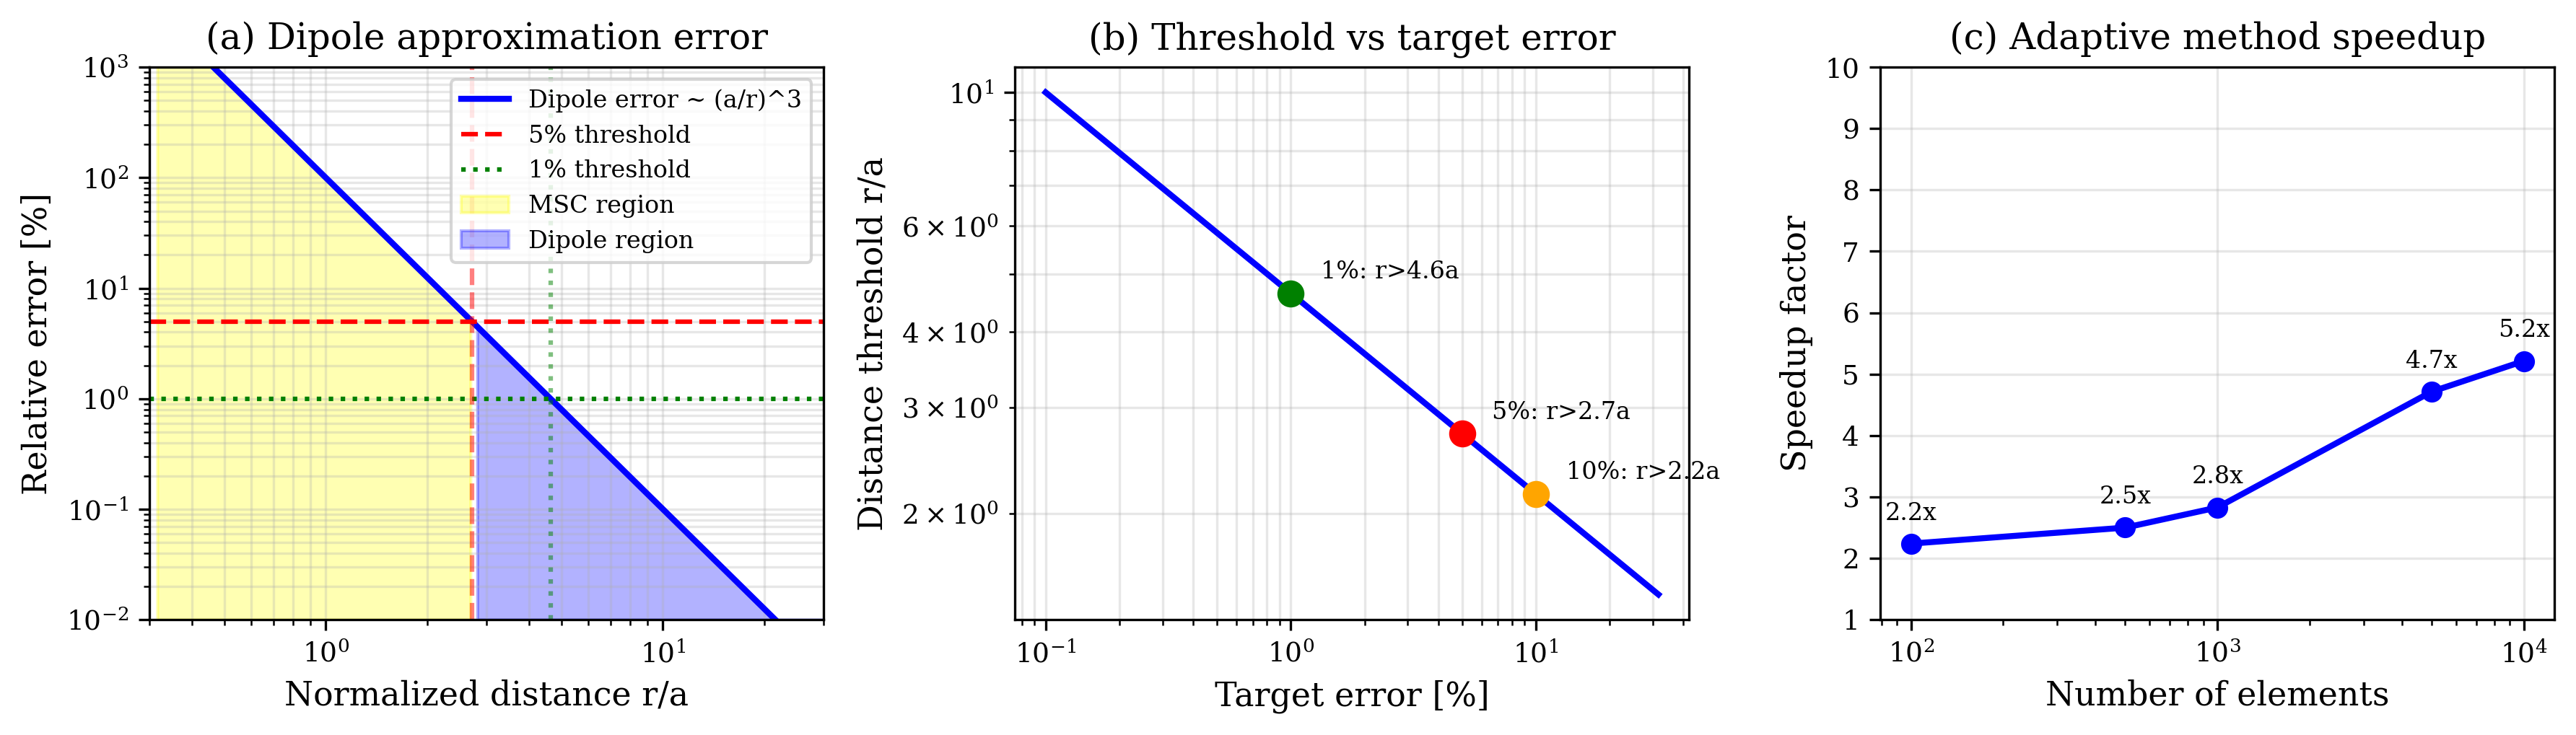

### `docs/peec_integration/figures/fig4_wpt_coil_85khz.png`  
sha256 `18f5b420710612a3`

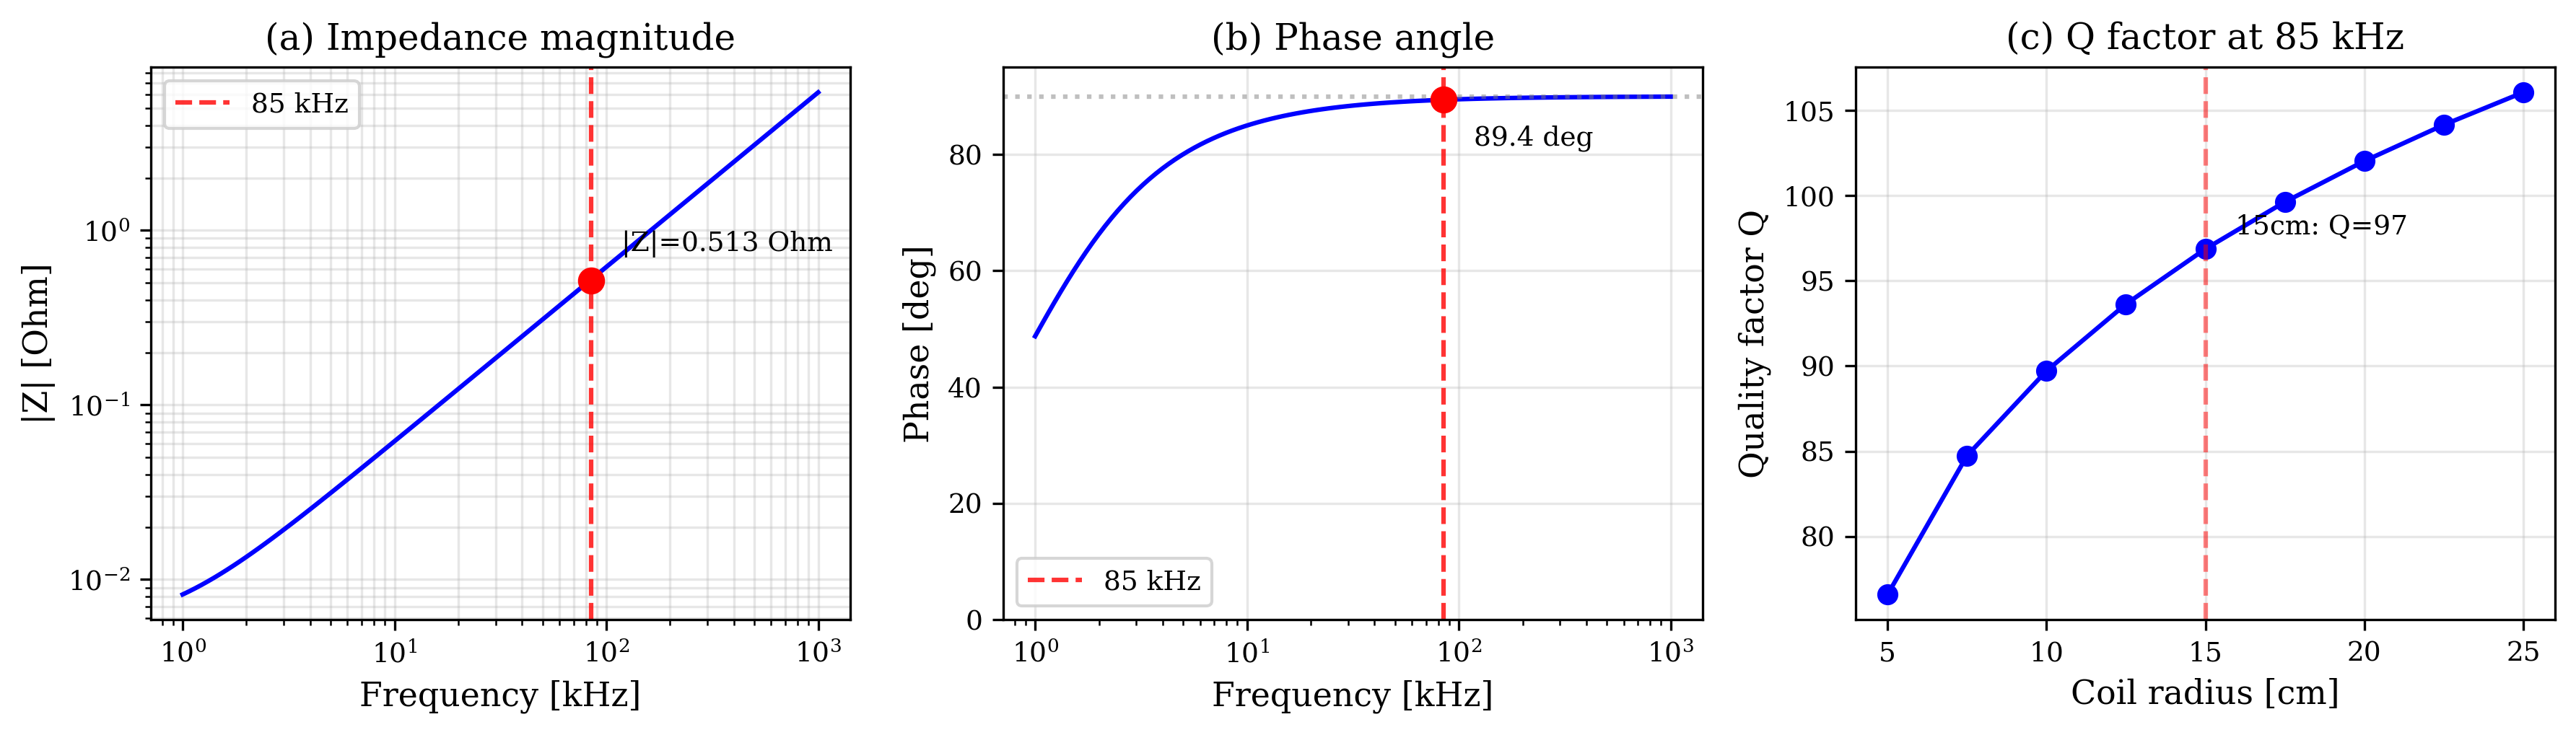

In [6]:
display(Markdown('## Saved figures from the verified PEEC showcase'))
for item in demo['selected_figures']:
    p = REPO / item['path']
    display(Markdown(f'### `{item["path"]}`  \nsha256 `{item["sha256"][:16]}`'))
    display(Image(filename=str(p), width=620))

In [7]:
protected = [r for r in catalog['records'] if r['protected_reference_count']]
rows=[]
for r in protected[:18]:
    first = r['protected_references'][0] if r['protected_references'] else {}
    where = f'{first.get("path", "")}:{first.get("line", "")}' if first else '-'
    rows.append([f'[`{r["path"]}`](../../{r["path"]})', r['protected_reference_count'], where, r['lane']])
md = '## Protected validation references\n\n' + '\n'.join(['| script | refs | first protected reference | lane |', '| --- | ---: | --- | --- |'] + [f'| {a} | {b} | {c} | {d} |' for a,b,c,d in rows])
display(Markdown(md))

## Protected validation references

| script | refs | first protected reference | lane |
| --- | ---: | --- | --- |
| [`examples/peec_integration/analysis/analyze_dowell_prima.py`](../../examples/peec_integration/analysis/analyze_dowell_prima.py) | 1 | src/radia.egg-info/SOURCES.txt:689 | docs_mor_spice_demo |
| [`examples/peec_integration/analysis/analyze_tet_ordering.py`](../../examples/peec_integration/analysis/analyze_tet_ordering.py) | 1 | src/radia.egg-info/SOURCES.txt:690 | docs_analysis_helper_or_retired_review |
| [`examples/peec_integration/analysis/compare_symmetrized_solve.py`](../../examples/peec_integration/analysis/compare_symmetrized_solve.py) | 1 | src/radia.egg-info/SOURCES.txt:691 | docs_analysis_helper_or_retired_review |
| [`examples/peec_integration/analysis/demo_analysis_framework.py`](../../examples/peec_integration/analysis/demo_analysis_framework.py) | 1 | src/radia.egg-info/SOURCES.txt:692 | docs_analysis_helper_or_retired_review |
| [`examples/peec_integration/analysis/evaluate_peec_formula_accuracy.py`](../../examples/peec_integration/analysis/evaluate_peec_formula_accuracy.py) | 1 | src/radia.egg-info/SOURCES.txt:693 | docs_analysis_helper_or_retired_review |
| [`examples/peec_integration/analysis/generate_paper_figures.py`](../../examples/peec_integration/analysis/generate_paper_figures.py) | 1 | src/radia.egg-info/SOURCES.txt:694 | docs_analysis_helper_or_retired_review |
| [`examples/peec_integration/analysis/measure_msc_asymmetry.py`](../../examples/peec_integration/analysis/measure_msc_asymmetry.py) | 1 | src/radia.egg-info/SOURCES.txt:695 | docs_analysis_helper_or_retired_review |
| [`examples/peec_integration/applications/demo_circular_coil_4cases.py`](../../examples/peec_integration/applications/demo_circular_coil_4cases.py) | 2 | docs/solver/NGBEM_INTEGRATION_DESIGN.md:933 | docs_application_demo |
| [`examples/peec_integration/applications/demo_dielectric.py`](../../examples/peec_integration/applications/demo_dielectric.py) | 2 | docs/api_inventory/API_SURFACE_2026-06-26.md:28 | docs_application_demo |
| [`examples/peec_integration/applications/demo_fasthenry_core_eddy.py`](../../examples/peec_integration/applications/demo_fasthenry_core_eddy.py) | 1 | src/radia.egg-info/SOURCES.txt:699 | docs_application_demo |
| [`examples/peec_integration/applications/demo_fasthenry_magnetic_core.py`](../../examples/peec_integration/applications/demo_fasthenry_magnetic_core.py) | 1 | src/radia.egg-info/SOURCES.txt:700 | docs_application_demo |
| [`examples/peec_integration/applications/demo_induction_heating.py`](../../examples/peec_integration/applications/demo_induction_heating.py) | 1 | src/radia.egg-info/SOURCES.txt:701 | docs_application_demo |
| [`examples/peec_integration/applications/demo_nmr_magnet.py`](../../examples/peec_integration/applications/demo_nmr_magnet.py) | 1 | src/radia.egg-info/SOURCES.txt:702 | docs_application_demo |
| [`examples/peec_integration/basic_peec/demo_frequency_response.py`](../../examples/peec_integration/basic_peec/demo_frequency_response.py) | 1 | src/radia.egg-info/SOURCES.txt:704 | docs_basic_peec_demo |
| [`examples/peec_integration/basic_peec/demo_loop_star.py`](../../examples/peec_integration/basic_peec/demo_loop_star.py) | 1 | src/radia.egg-info/SOURCES.txt:705 | docs_basic_peec_demo |
| [`examples/peec_integration/basic_peec/demo_peec_dc.py`](../../examples/peec_integration/basic_peec/demo_peec_dc.py) | 1 | src/radia.egg-info/SOURCES.txt:706 | docs_basic_peec_demo |
| [`examples/peec_integration/basic_peec/demo_peec_from_1d_mesh.py`](../../examples/peec_integration/basic_peec/demo_peec_from_1d_mesh.py) | 1 | src/radia.egg-info/SOURCES.txt:707 | docs_basic_peec_demo |
| [`examples/peec_integration/basic_peec/demo_peec_from_dual_mesh.py`](../../examples/peec_integration/basic_peec/demo_peec_from_dual_mesh.py) | 1 | src/radia.egg-info/SOURCES.txt:708 | docs_basic_peec_demo |

In [8]:
for r in demo['selected_records'][:3]:
    excerpt = r['source']['text'][:1100].replace('```', '` ` `')
    display(Markdown(f'## Source excerpt: `{r["path"]}`\n\n```python\n{excerpt}\n```'))

## Source excerpt: `examples/peec_integration/basic_peec/demo_peec_simple_loop.py`

```python
"""
Simple PEEC Analysis for Circular Coil

Uses Radia's verified PEEC solver with analytical loop geometry.
Compares with GMSH mesh for validation.

This is the CORRECT approach - use the working PEEC solver!
"""

import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(__file__), '../../../src/radia'))

import numpy as np
from pathlib import Path

print("=" * 70)
print("PEEC Analysis - Circular Coil")
print("Using Radia's Verified PEEC Solver")
print("=" * 70)

# Import PEEC module
try:
    from peec_matrices import PEECBuilder
    print("\nUsing C++ PEEC implementation")
except ImportError:
    print("\nERROR: PEEC module not available")
    sys.exit(1)

# Coil parameters (from GMSH mesh specification)
radius = 50e-3  # m (50mm mean radius)
width = 4e-3    # m (4mm wire width)
height = 4e-3   # m (4mm wire height)
n_segments = 36  # Number of segments
sigma = 5.8e7    # S/m (copper)

print(f"\n[1] Coil parameters:")
print(f"    Radius: {radius*1e3:.1f} mm")
print(f"    Wire cross-section: {width*1e3:.1f} x {height*1e3:.1f} mm")
print(f"    Segments: {n_segments}")
prin
```

## Source excerpt: `examples/peec_integration/basic_peec/demo_frequency_response.py`

```python
"""
Demonstration of Frequency Response Analysis

This script demonstrates frequency response analysis for both:
1. PEEC conductors (impedance Z(f) with skin effect)
2. MMM magnetic materials (complex permeability mu(f) with H-dependence)

The examples show:
- DC to 10 MHz frequency sweep
- Dowell skin effect correction for conductors
- H-dependent permeability for nonlinear magnetic materials
- Comparison of different operating H levels

Author: Radia Development Team
Date: 2026-01-15
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add build path
sys.path.insert(0, os.path.join(os.path.dirname(__file__), '../../../build-msvc'))
sys.path.insert(0, os.path.join(os.path.dirname(__file__), '../../../src/radia'))

# Import analysis framework
from analysis import (
    UnifiedAnalysis,
    UnifiedMMMAnalysis,
    MU_0,
)


def create_coil_peec_model():
    """
    Create PEEC matrices for a multi-turn coil.

    Returns:
        L: Inductance matrix [H]
        R: Resistance matrix [Ohm]
    """
    # Coil parameters
    n_turns = 20
    r_coil = 0.03      
```

## Source excerpt: `examples/peec_integration/gmsh_models/demo_gmsh_ports_peec.py`

```python
"""
PEEC Analysis with Port-Defined GMSH Mesh

Workflow:
    1. Load GMSH mesh with port definitions (circular_coil_with_ports.msh)
    2. Extract port regions (port_positive, port_negative)
    3. Build PEEC model from mesh edges
    4. Create port excitation vector
    5. Compute port-to-port impedance

Port Configuration:
    - port_positive (phi=0, +X): Voltage applied
    - port_negative (phi=180, -X): Ground
    - Z_port = V_applied / I_total (two-port impedance)

FastMaxwell Integration:
    - Mesh edges -> PEEC segments
    - Port regions -> Excitation vector
    - Loop-Star decomposition

Author: Radia Development Team
Date: 2026-02-12
"""

import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(__file__), '../../../src/radia'))

import numpy as np
from pathlib import Path

GMSH_MODELS = Path(__file__).resolve().parent
from gmsh_ascii_reader import read_gmsh_ascii

print("=" * 70)
print("PEEC Analysis with Port-Defined GMSH Mesh")
print("Using Radia PEEC Solver (FastMaxwell-based)")
print("=" * 70)

# Import PEEC module
try:
    from peec_matrices import PEECBui
```

In [9]:
assert demo['summary']['selected_demo_count'] == len(demo['selected_records'])
assert demo['summary']['cleanup_review_count'] == len(catalog.get('cleanup_review', []))
assert catalog['summary']['script_count'] == demo['summary']['catalog_script_count']
print('peec_integration public demo synchronized; archive includes cleanup-review candidates, not all public demos')

peec_integration public demo synchronized; archive includes cleanup-review candidates, not all public demos
